# Assignments - Digital options

Create a new folder under <b>QuantCourseBP\homeworks</b> and copy over the content of this lecture's solution folder to start with.

1. Get familiar with digital options and implement EuropeanDigitalContract and EuropeanDigitalAnalyticPricer (fair value and greeks) in the library. Implement unit test for fair value using pytest. **(12 points)**
2. Get familiar with bull spread options and by utilizing EuropeanDigitalAnalyticPricer and EuropeanAnalyticPricer, create a figure to visualize that a digital call option can be thought of as a limit of bull spread call options. **(8 points)**

2. Feladat

Egy bull spread egy long call alacsony strikeon és short call magasabb strikeon. Először rajzoltassuk ki a kifizetésfüggvényét egy ilyen stratégiának.

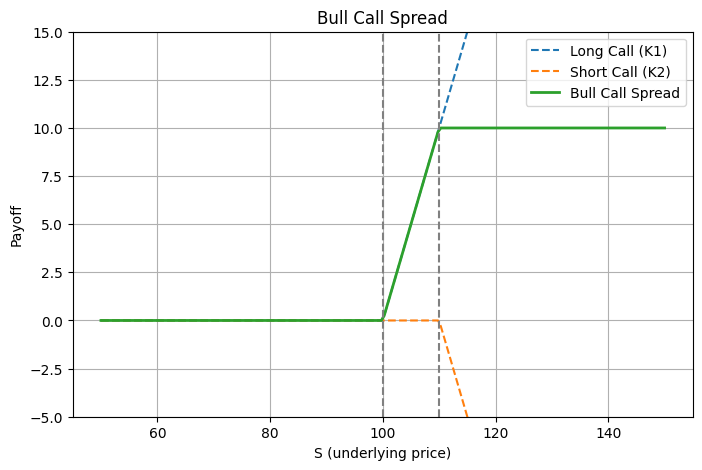

In [67]:
import numpy as np
import matplotlib.pyplot as plt

K1 = 100
K2 = 110

S = np.linspace(50, 150, 200)

long_call = np.maximum(S - K1, 0)
short_call = -np.maximum(S - K2, 0)

bull_spread = long_call + short_call

plt.figure(figsize=(8,5))

plt.plot(S, long_call, '--', label="Long Call (K1)")
plt.plot(S, short_call, '--', label="Short Call (K2)")
plt.plot(S, bull_spread, linewidth=2, label="Bull Call Spread")

# strike jelölések
plt.axvline(K1, linestyle='--', color='gray')
plt.axvline(K2, linestyle='--', color='gray')

plt.xlabel("S (underlying price)")
plt.ylabel("Payoff")
plt.title("Bull Call Spread")

plt.ylim(-5,15)

plt.legend()
plt.grid()

plt.show()

Ha simán azt csinálnánk, hogy a két kötési árfolyam közti különbséget csökkentjük, akkor teljesen eltűnik a köztes rész, és egy 0-val egyenlő konstans kifizetést kapnánk. Tehát úgy kapjuk a 
határértéket, ha annyi spreadet vásárolunk, amekkora a kötési árfolyamok közti különbség. Legyen ez a különbség epsilon. Ekkor normalizáltuk a maximum kifizetést minden epsilon esetén 1-re és ha 
epsilonnal 0-hoz tartunk, akkor egy olyan kifizetésfüggvényt fogunk kapni, ahol K-ig 0 a kifizetés és K-tól 1.

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_bull_spread(epsilon=10.0):
    K1 = 100
    K2 = K1 + epsilon

    S = np.linspace(50, 150, 400)

    long_call = np.maximum(S - K1, 0)
    short_call = -np.maximum(S - K2, 0)
    bull_spread = (long_call + short_call) / epsilon

    plt.figure(figsize=(8,5))
    plt.plot(S, bull_spread, linewidth=2, label="Scaled Bull Spread")

    plt.xlabel("S (underlying price)")
    plt.ylabel("Payoff")
    plt.title(f"Scaled Bull Call Spread Payoff, epsilon = {epsilon:.2f}")

    plt.xlim(50, 150)
    plt.ylim(-2, 3)
    plt.legend()
    plt.grid()
    plt.show()

interact(
    plot_bull_spread,
    epsilon=FloatSlider(value=10.0, min=0.05, max=20.0, step=0.5)
)

interactive(children=(FloatSlider(value=10.0, description='epsilon', max=20.0, min=0.05, step=0.5), Output()),…

<function __main__.plot_bull_spread(epsilon=10.0)>

Most pedig akkor azt ellenőrizzük, hogy 1/epsilon számú bullish spread értéke tényleg megegyezik-e egy digital option árával.

In [69]:
import numpy as np

from pricer import *
from contract import *
from enums import *
from market_data import *
from model import *

underlying = Stock.BLUECHIP_BANK
model = MarketModel(underlying)
params = Params()

K = model.spot
T = 1.0
epsilon = 0.1

# call K strike
call_K = EuropeanContract(
    underlying,
    PutCallFwd.CALL,
    LongShort.LONG,
    K,
    T
)
pricer_call_K = EuropeanAnalyticPricer(call_K, model, params)
price_call_K = pricer_call_K.calc_fair_value()

# call K + epsilon strike
call_K_eps = EuropeanContract(
    underlying,
    PutCallFwd.CALL,
    LongShort.SHORT,
    K + epsilon,
    T
)
pricer_call_K_eps = EuropeanAnalyticPricer(call_K_eps, model, params)
price_call_K_eps = pricer_call_K_eps.calc_fair_value()

# spread közelítés
bull_spread_approx = (price_call_K + price_call_K_eps) / epsilon

# digital call
digital_contract = EuropeanDigitalContract(
    underlying,
    PutCallFwd.CALL,
    LongShort.LONG,
    K,
    T
)
digital_pricer = EuropeanDigitalAnalyticPricer(digital_contract, model, params)
digital_price = digital_pricer.calc_fair_value()

print(f"Spot = {model.spot:.6f}")
print(f"K = {K:.6f}")
print(f"T = {T:.6f}")
print(f"epsilon = {epsilon:.6f}")
print()
print(f"Call(K)            = {price_call_K:.10f}")
print(f"Call(K+epsilon)    = {price_call_K_eps:.10f}")
print(f"Scaled bull spread = {bull_spread_approx:.10f}")
print(f"Digital call price = {digital_price:.10f}")
print(f"Difference         = {abs(bull_spread_approx - digital_price):.10f}")

Spot = 130.170000
K = 130.170000
T = 1.000000
epsilon = 0.100000

Call(K)            = 22.5240460274
Call(K+epsilon)    = -22.4787704953
Scaled bull spread = 0.4527553208
Digital call price = 0.4531371227
Difference         = 0.0003818019


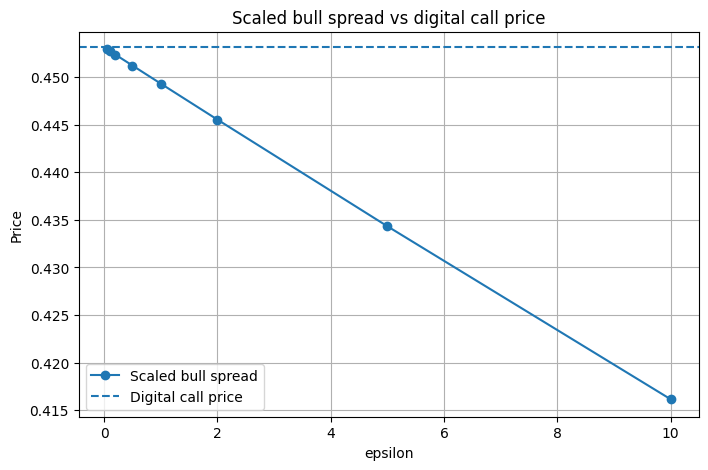

In [70]:
# epsilon values
eps_values = np.array([10.0, 5.0, 2.0, 1.0, 0.5, 0.2, 0.1, 0.05])
approx_values = []

for eps in eps_values:
    call_long = EuropeanContract(
        underlying,
        PutCallFwd.CALL,
        LongShort.LONG,
        K,
        T
    )
    call_short = EuropeanContract(
        underlying,
        PutCallFwd.CALL,
        LongShort.SHORT,
        K + eps,
        T
    )

    pricer_long = EuropeanAnalyticPricer(call_long, model, params)
    pricer_short = EuropeanAnalyticPricer(call_short, model, params)

    bull_spread_price = pricer_long.calc_fair_value() + pricer_short.calc_fair_value()
    scaled_bull_spread = bull_spread_price / eps
    approx_values.append(scaled_bull_spread)


plt.figure(figsize=(8,5))
plt.plot(eps_values, approx_values, marker='o', label='Scaled bull spread')
plt.axhline(digital_price, linestyle='--', label='Digital call price')

plt.xlabel('epsilon')
plt.ylabel('Price')
plt.title('Scaled bull spread vs digital call price')
plt.grid()
plt.legend()



plt.show()